Library

In [17]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

Input Path

In [18]:
model_path = "runs/detect/11s_lr_augment/weights/best.pt"
image_path = "test2.jpg"

Load Best Model

In [19]:
best_model = YOLO(model_path)

In [20]:
class_names = ['WBC', 'RBC', 'Platelets']

colors = {
    'WBC': (255, 0, 0),        # Biru
    'RBC': (0, 255, 0),        # Hijau
    'Platelets': (0, 0, 255)   # Merah
}

def visualize_inference(image_path, model, conf_threshold=0.25):
    img = cv2.imread(image_path)

    results = model(img)[0]

    boxes = results.boxes.xyxy
    scores = results.boxes.conf
    classes = results.boxes.cls

    for box, score, cls in zip(boxes, scores, classes):
        if score < conf_threshold:
            continue

        x1, y1, x2, y2 = map(int, box)
        label = class_names[int(cls)]
        color = colors[label]

        # Draw bounding box
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()


0: 512x640 (no detections), 11.1ms
Speed: 1.8ms preprocess, 11.1ms inference, 0.5ms postprocess per image at shape (1, 3, 512, 640)


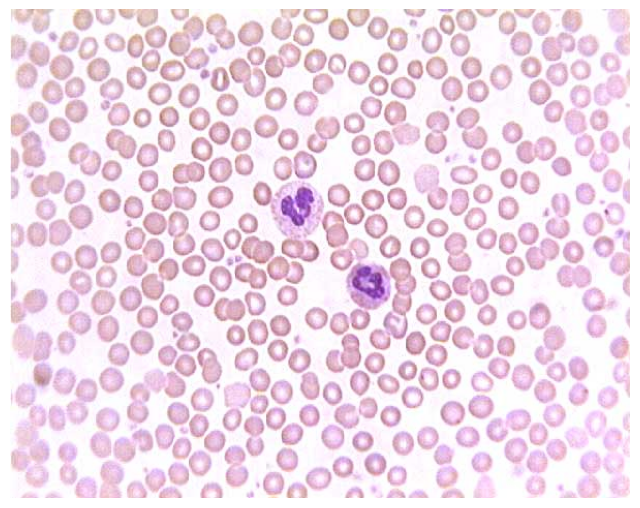

In [21]:
visualize_inference(image_path, best_model)

SAHI

In [22]:
from sahi import AutoDetectionModel

detection_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path="runs/detect/11s_lr_augment/weights/best.pt",
    confidence_threshold=0.25,
    device="cuda"
)

In [23]:
from sahi.predict import get_sliced_prediction

result = get_sliced_prediction(
    "test2.jpg",
    detection_model,
    slice_height=256,
    slice_width=256,
    overlap_height_ratio=0.2,
    overlap_width_ratio=0.2
)

Performing prediction on 9 slices.


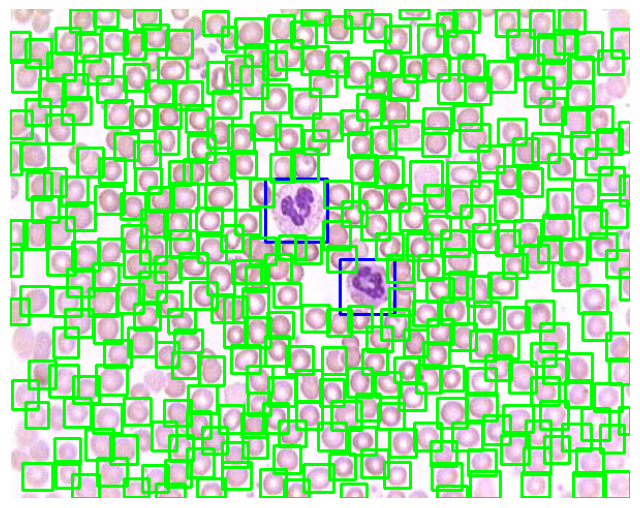

In [24]:
colors = {
    'WBC': (255, 0, 0),
    'RBC': (0, 255, 0),
    'Platelets': (0, 0, 255)
}

img = cv2.imread("test2.jpg")

for obj in result.object_prediction_list:
    bbox = obj.bbox
    x1, y1, x2, y2 = map(int, [bbox.minx, bbox.miny, bbox.maxx, bbox.maxy])
    
    label = obj.category.name
    score = obj.score.value

    color = colors.get(label, (255, 255, 255)) 

    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()